In [1]:
import ast
import pandas as pd 
from datasets import load_dataset
import matplotlib.pyplot as plt 
import seaborn as  sns

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date']= pd.to_datetime(df['job_posted_date'])
df['job_skills']= df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x) 

c:\Users\TOLU\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/lukebarousse/data_jobs/resolve/ed776e5a0a8c40ea9d5efbd800772ae52e140f3e/data_jobs.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since lukebarousse/data_jobs couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\TOLU\.cache\huggingface\datasets\lukebarousse___data_jobs\default\0.0.0\ed776e5a0a8c40ea9d5efbd800772ae52e140f3e (last modified on Thu Mar  5 19:06:55 2026).


In [2]:
df_DA_US=df[(df['job_country']== 'United States') & (df['job_title_short']== 'Data Analyst')].copy()

In [3]:
df_DA_US['job_posted_month']= df_DA_US['job_posted_date'].dt.month

In [5]:
df_DA_US_exploded = df_DA_US.explode('job_skills')

In [19]:
df_DA_pivot=df_DA_US_exploded.pivot_table(index='job_posted_month',columns='job_skills',aggfunc='size',fill_value=0)

In [21]:
df_DA_pivot.loc['total']= df_DA_pivot.sum(axis=0)
df_DA_pivot

job_skills,airflow,airtable,alteryx,angular,ansible,apl,arch,asana,asp.net,asp.net core,...,watson,webex,windows,wire,word,workfront,wrike,xamarin,yarn,zoom
job_posted_month,,,,,,,,,,,,,,,,,,,,,
1,39,7,206,21,7,1,0,15,17,0,...,7,9,80,3,968,0,7,0,0,30
2,35,0,203,23,4,1,0,14,9,0,...,6,6,92,3,738,3,0,0,0,19
3,39,1,219,5,5,6,1,14,11,0,...,7,6,76,5,736,1,1,1,0,16
4,28,1,208,8,3,7,3,5,6,0,...,2,4,86,9,695,8,1,0,0,12
5,27,3,144,15,8,9,1,5,13,0,...,1,6,67,1,557,3,0,0,0,9
6,39,5,188,9,4,8,3,7,7,0,...,5,2,69,8,721,5,0,0,0,20
7,42,2,160,5,3,5,5,6,2,0,...,4,1,59,10,587,0,0,0,1,13
8,44,2,187,5,3,10,0,5,3,0,...,3,6,87,4,752,0,0,0,0,26
9,22,3,145,11,2,3,4,4,3,0,...,0,4,80,4,478,0,0,0,1,12


In [26]:
df_DA_pivot= df_DA_pivot[df_DA_pivot.loc['total'].sort_values(ascending= False).index]
df_DA_pivot=df_DA_pivot.drop('total')

In [28]:
dA_totals=df_DA_US.groupby('job_posted_month').size()

In [32]:
df_DA_percent=df_DA_pivot.div(other=dA_totals/100,axis= 0)

In [34]:
df_DA_US_percent = df_DA_percent.reset_index()

df_DA_US_percent['job_posted_month'] = df_DA_US_percent['job_posted_month'].apply(
    lambda x: pd.to_datetime(x, format='%m').strftime('%b')
)

df_DA_US_percent = df_DA_US_percent.set_index('job_posted_month')

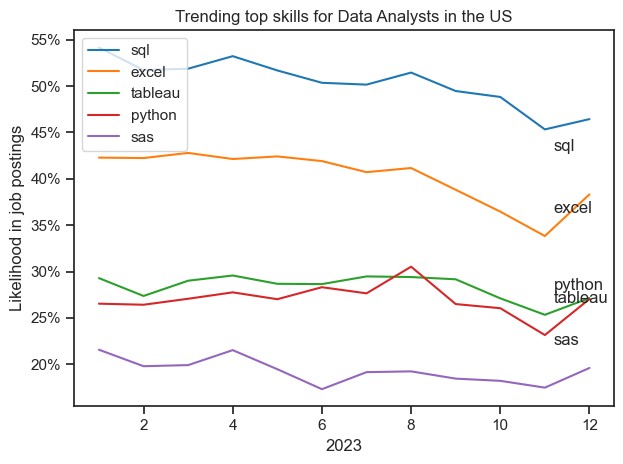

In [ ]:
df_plot = df_DA_percent.iloc[:, :5]

sns.lineplot(data= df_plot,dashes=False,palette= 'tab10' )
sns.set_theme(style='ticks')
plt.title('Trending top skills for Data Analysts in the US')
plt.xlabel('2023')
plt.ylabel('Likelihood in job postings')
plt.legend(loc='upper left')

from matplotlib.ticker import PercentFormatter
ax= plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

for i in range(5):
    y=df_plot.iloc[-1,i]
    plt.text(11.2, y+(i-2)*1.5,df_plot.columns[i],va= 'center')
plt.tight_layout()